# Teste — módulo de coleta

**Kernel:** conda `moradinha`  
**Diretório de trabalho:** deve ser `e:/Doutorado/UFABC/moradinha/` (raiz do projeto)

In [62]:
import logging
import sys
from pathlib import Path

# Detecta a raiz do projeto subindo a partir do cwd até encontrar modulo_coleta/
def _encontrar_raiz() -> Path:
    candidato = Path.cwd()
    for _ in range(6):
        if (candidato / "modulo_coleta").is_dir():
            return candidato
        candidato = candidato.parent
    raise FileNotFoundError(
        f"Raiz do projeto não encontrada a partir de '{Path.cwd()}'. "
        "Execute o notebook com o cwd dentro da pasta do projeto."
    )

ROOT = _encontrar_raiz()
print(f"ROOT detectado: {ROOT}")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Logging legível no notebook
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,
)

print("OK")

ROOT detectado: d:\Doutorado\UFABC\moradinha
OK


In [63]:
import importlib
import modulo_coleta.orquestrador as orchestrator
importlib.reload(orchestrator)
from modulo_coleta.orquestrador import coletar_municipio

## Parâmetros

Edite o código IBGE e os grupos desejados antes de rodar.

In [64]:
CODIGO_IBGE   = "2701407"          # Campo Alegre-AL (usado nos testes anteriores)
NOME_PASTA    = "al_campo_alegre"  # None = derivado automaticamente via geobr
GRUPOS        = [1, 2, 3, 4, 5]   # remova grupos que não quer coletar
BASE_DIR      = ROOT / "data"
FORCAR        = False              # True = reprocessa mesmo que arquivos já existam

In [ ]:
resultados = coletar_municipio(
    codigo_ibge=CODIGO_IBGE,
    grupos=GRUPOS,
    base_dir=BASE_DIR,
    nome_municipio=NOME_PASTA,
    forcar=FORCAR,
)

22:54:08 [INFO] Município: al_campo_alegre (IBGE: 2701407)
22:54:08 [INFO] DuckDB aberto: d:\Doutorado\UFABC\moradinha\data\processed\al_campo_alegre\al_campo_alegre.duckdb
22:54:08 [INFO] ============================================================
22:54:08 [INFO] Iniciando grupo1_geometrias...
22:54:08 [INFO] [Grupo 1] Limite municipal
22:54:08 [INFO] Baixando limite municipal via geobr (codigo_ibge=2701407)
22:54:09 [INFO] Created 1 records
22:54:10 [ERROR] [Grupo 1] Erro: [Errno 28] Error writing bytes to file. Detail: [errno 28] No space left on device
Traceback (most recent call last):
  File "d:\Doutorado\UFABC\moradinha\modulo_coleta\grupos\grupo1_geometrias.py", line 199, in coletar_grupo1
    salvar_geodataframe(db_conn, limite_municipal, "limite_municipal")
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Doutorado\UFABC\moradinha\modulo_coleta\utils\db_utils.py", line 142, in salvar_geodataframe
    df_para_salvar.to_parquet(tmp_path, index=

d:\Doutorado\UFABC\moradinha\modulo_coleta\utils\db_utils.py:140: UserWarning: Geometry column does not contain geometry.
  df_para_salvar["geometry"] = gdf.geometry.apply(lambda geom: geom.wkb)


22:54:19 [INFO] Filtro municipio 2701407: 72/458772 setores retidos
22:54:19 [INFO] [Grupo 2] CSV salvo: censo_domicilio01.csv (72 linhas)
22:54:19 [INFO] Tabela 'censo_domicilio01' salva: 72 registros.
22:54:19 [INFO] [Grupo 2] Baixando censo_domicilio02
22:54:19 [INFO] ZIP ja existe (pulando download): Agregados_por_setores_caracteristicas_domicilio2_BR_20250417.zip
22:54:19 [INFO] Lendo Agregados_por_setores_caracteristicas_domicilio2_BR_20250417.csv de Agregados_por_setores_caracteristicas_domicilio2_BR_20250417.zip
22:54:22 [ERROR] [Grupo 2] Erro: Error tokenizing data. C error: out of memory
Traceback (most recent call last):
  File "d:\Doutorado\UFABC\moradinha\modulo_coleta\grupos\grupo2_censo.py", line 186, in coletar_grupo2
    df = _baixar_e_filtrar_csv(codigo_ibge, url_base, prefixo, output_dir, forcar=forcar)
  File "d:\Doutorado\UFABC\moradinha\modulo_coleta\grupos\grupo2_censo.py", line 121, in _baixar_e_filtrar_csv
    df = pd.read_csv(
        io.TextIOWrapper(f, encod

## Resumo dos resultados

In [ ]:
from modulo_coleta.orquestrador import GRUPOS_DISPONIVEIS

for grupo, res in resultados.items():
    if grupo in ("mapa", "fig"):
        continue
    nome  = GRUPOS_DISPONIVEIS.get(grupo, f"grupo{grupo}")
    status = res.get("status", "?")
    camadas = res.get("camadas", [])
    msg    = res.get("mensagem", "")
    icone  = "✅" if status == "ok" else ("⏭️" if status == "pulado" else "❌")
    print(f"{icone} Grupo {grupo} ({nome}): {status}")
    if camadas:
        print(f"   camadas: {camadas}")
    if status != "ok":
        print(f"   msg: {msg}")

❌ Grupo 1 (grupo1_geometrias): erro
   msg: [Errno 28] Error writing bytes to file. Detail: [errno 28] No space left on device
❌ Grupo 2 (grupo2_censo): erro
   camadas: ['censo_domicilio01']
   msg: Error tokenizing data. C error: out of memory
❌ Grupo 3 (grupo3_logradouros): erro
   msg: limite_municipal é obrigatório para o Grupo 3.
✅ Grupo 4 (grupo4_luminosidade): ok
   camadas: ['luminosidade_2022', 'luminosidade_2022_grade200']
✅ Grupo 5 (grupo5_pnadc): ok
   camadas: ['pnadc_estimativas', 'pnadc_metadados']


## Mapa de coleta

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt

fig = resultados.get("fig")
if fig is not None:
    display(fig)
    plt.close(fig)
else:
    print("Mapa não gerado.")

Mapa não gerado.


## Inspecionar o DuckDB

Célula opcional para checar as tabelas geradas.

In [ ]:
from modulo_coleta.utils.db_utils import abrir_conexao, listar_tabelas

db_path = BASE_DIR / "processed" / NOME_PASTA / f"{NOME_PASTA}.duckdb"
conn = abrir_conexao(db_path)
tabelas = listar_tabelas(conn)
print(f"Tabelas no banco ({NOME_PASTA}):")
for t in tabelas:
    n = conn.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"  {t}: {n} registros")
conn.close()

18:05:25 [INFO] DuckDB aberto: d:\Doutorado\UFABC\moradinha\data\processed\al_campo_alegre\al_campo_alegre.duckdb
Tabelas no banco (al_campo_alegre):
  areas_ponderacao: 2 registros
  censo_domicilio01: 72 registros
  censo_domicilio02: 72 registros
  censo_responsavel01: 72 registros
  eixos_osm: 3294 registros
  enderecos_cnefe: 14966 registros
  faces_logradouro: 1682 registros
  grade_estatistica: 976 registros
  limite_municipal: 1 registros
  luminosidade_2022: 66 registros
  luminosidade_2022_grade200: 976 registros
  pnadc_estimativas: 1 registros
  pnadc_metadados: 14 registros
  setores_censitarios: 66 registros


22:51:22 [INFO] Tabela 'grade_estatistica' lida do DuckDB: 976 feições.
22:51:22 [INFO] Tabela 'setores_censitarios' lida do DuckDB: 66 feições.
22:51:22 [INFO] Tabela 'areas_ponderacao' lida do DuckDB: 2 feições.
22:51:22 [INFO] Tabela 'faces_logradouro' lida do DuckDB: 1682 feições.
22:51:22 [INFO] Tabela 'eixos_osm' lida do DuckDB: 3294 feições.
22:51:23 [INFO] Tabela 'enderecos_cnefe' lida do DuckDB: 14966 feições.
22:51:23 [INFO] Tabela 'limite_municipal' lida do DuckDB: 1 feições.
22:51:24 [INFO] Mapa salvo em: d:\Doutorado\UFABC\moradinha\data\processed\al_campo_alegre\teste_mapa.png
fig type: <class 'matplotlib.figure.Figure'>
output file exists: True


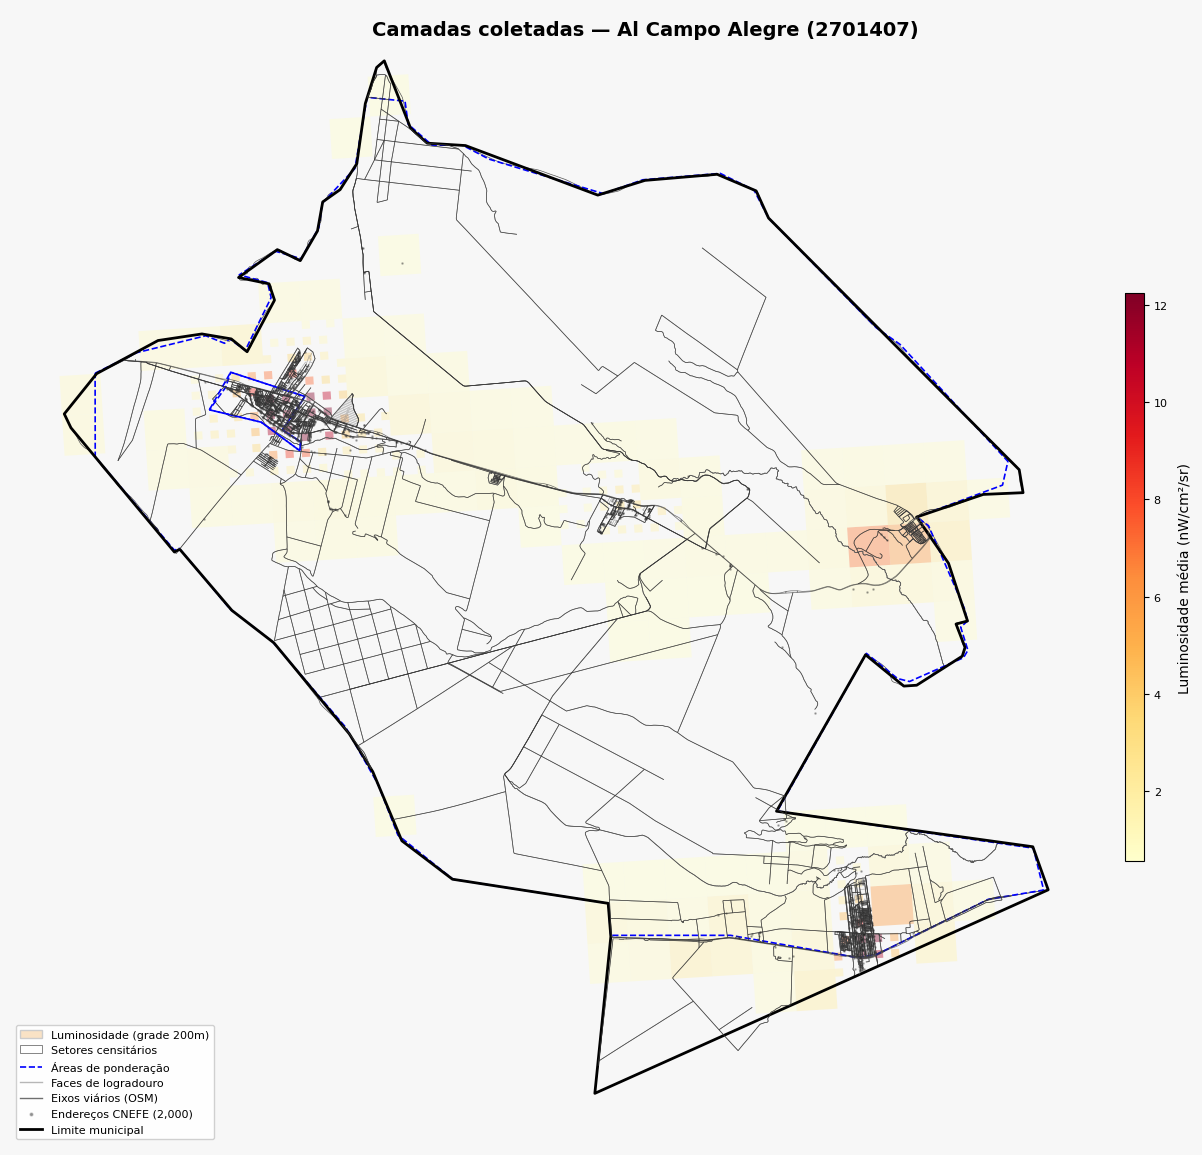

In [ ]:
import importlib
import modulo_coleta.orquestrador as orchestrator
importlib.reload(orchestrator)
from modulo_coleta.orquestrador import _gerar_mapa
import duckdb

db_path = BASE_DIR / 'processed' / NOME_PASTA / f'{NOME_PASTA}.duckdb'
output_png = BASE_DIR / 'processed' / NOME_PASTA / 'teste_mapa.png'
conn = duckdb.connect(db_path)
fig = _gerar_mapa(conn, NOME_PASTA, output_png, CODIGO_IBGE)
print('fig type:', type(fig))
print('output file exists:', output_png.exists())
conn.close()